# PCHN63112 Workshop: Introduction to Mixed-effects 

## Multiple Within-subject Factors
We will start with an example of a mixed-effects model applied to multiple within-subject factors. As with last week, we will use the `weightloss` dataset included with `datarium`. Below is the code for loading the data, restructuring it into long-format and then printing the values associated with the first subject.

In [1]:
library('datarium')
library('reshape2')

data('weightloss')

# repeats and number of subjects
t <- 12 # 2 * 2 * 3
n <- 12

# reshape wide -> long
weightloss.long <- melt(weightloss,                         # wide data frame
                        id.vars=c('id','diet','exercises'), # what stays fixed?
                        variable.name="time",               # name for the new predictor
                        value.name="weight")                # name for the new outcome

weightloss.long           <- weightloss.long[order(weightloss.long$id),] # order by ID
rownames(weightloss.long) <- seq(1,n*t)                                  # fix row names

weightloss.long$id        <- as.factor(weightloss.long$id)               # id as factor
weightloss.long$diet      <- as.factor(weightloss.long$diet)             # diet as factor
weightloss.long$exercises <- as.factor(weightloss.long$exercises)        # exercises as factor
weightloss.long$time      <- as.factor(weightloss.long$time)             # time as factor

weightloss.long[weightloss.long$id == '1',]

   id diet exercises time weight
1   1   no        no   t1  10.43
2   1   no       yes   t1  11.12
3   1  yes        no   t1  10.20
4   1  yes       yes   t1  10.43
5   1   no        no   t2  13.21
6   1   no       yes   t2  12.51
7   1  yes        no   t2  12.51
8   1  yes       yes   t2  12.51
9   1   no        no   t3  11.59
10  1   no       yes   t3  15.76
11  1  yes        no   t3  14.60
12  1  yes       yes   t3  14.37

### Basic Random-effects Structure
The most basic model we can fit includes a random intercept per-subject. We will discuss the process of building these models in more detail next week, so do not worry too much about how this decision has been reached. The aim here is just to see more examples of basic mixed-effects models and how they work. We can specify this using `lme()` below, using the syntax `random= ~ 1|id` for the random-effects.

In [2]:
library(nlme)
weightloss.lme.0 <- lme(weight ~ diet*exercises*time, random= ~ 1|id, data=weightloss.long)
summary(weightloss.lme.0)

Linear mixed-effects model fit by REML
  Data: weightloss.long 
       AIC      BIC    logLik
  469.9397 510.2989 -220.9699

Random effects:
 Formula: ~1 | id
        (Intercept) Residual
StdDev:    0.317161 1.120828

Fixed effects:  weight ~ diet * exercises * time 
                                Value Std.Error  DF  t-value p-value
(Intercept)                 10.909167 0.3362595 121 32.44270  0.0000
dietyes                      0.833333 0.4575760 121  1.82119  0.0710
exercisesyes                -0.115000 0.4575760 121 -0.25132  0.8020
timet2                       0.656667 0.4575760 121  1.43510  0.1538
timet3                       0.540833 0.4575760 121  1.18195  0.2395
dietyes:exercisesyes        -0.234167 0.6471102 121 -0.36187  0.7181
dietyes:timet2               0.016667 0.6471102 121  0.02576  0.9795
dietyes:timet3               1.503333 0.6471102 121  2.32315  0.0218
exercisesyes:timet2          1.970000 0.6471102 121  3.04430  0.0029
exercisesyes:timet3          5.482500 0.64

Notice that there are only *two* variances in this model, as indicated by `StdDev` under the `Random effects:` section. This indicates already that this model is assuming *compound symmetry* and so, at present, is not much improvement over a repeated measures ANOVA. Putting this to one side, we can generate an ANOVA table as usual

In [3]:
library(car)
Anova(weightloss.lme.0)

Loading required package: carData


Analysis of Deviance Table (Type II tests)

Response: weight
                       Chisq Df Pr(>Chisq)    
diet                  4.0687  1    0.04368 *  
exercises            56.6472  1  5.215e-14 ***
time                168.2687  2  < 2.2e-16 ***
diet:exercises       26.5860  1  2.521e-07 ***
diet:time             1.9260  2    0.38174    
exercises:time       53.6780  2  2.208e-12 ***
diet:exercises:time  24.4971  2  4.792e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

which is suggestive of a 3-way interaction between `diet`, `exercises` and `time`. We can plot this using `effects`

lattice theme set by effectsTheme()
See ?effectsTheme for details.


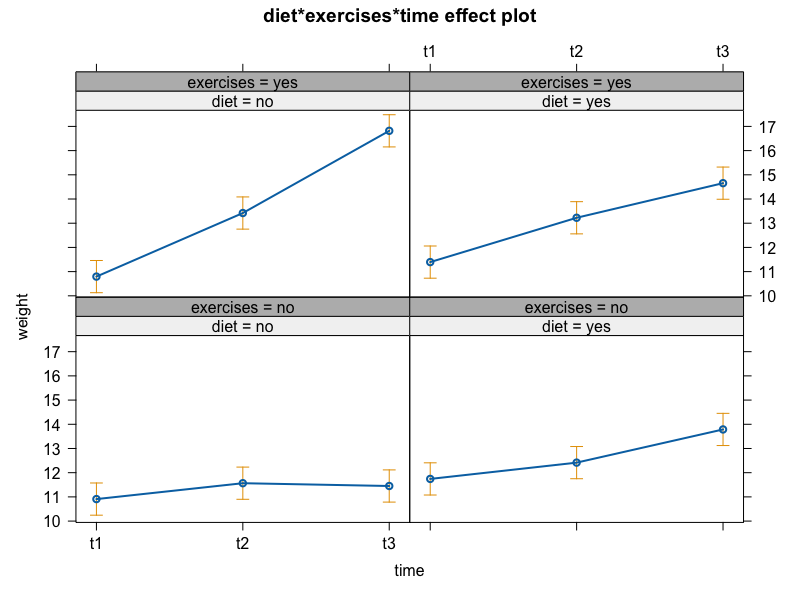

In [4]:
library(effects)
plot(effect('diet:exercises:time', weightloss.lme.0))

which is strongly suggestive of a combined effect of both `diet` and `exercises` on the amount of weight loss over time. 

<div class="alert alert-block alert-info"> 
<b>ACTIVITY 1</b> Can you go back to the materials from semester 1 and work out how to break this interaction down using <code>emmeans</code>?
</div>

### Multilevel Conceptualisation
To connect with the materials from the lesson, the multilevel conceptualisation of this model is as follows

$$
\begin{alignat*}{1}
\text{Level 1}\\
    y_{ijkl} &= \mu_{i} + \alpha_{j} + \beta_{k} + \gamma_{l} + (\alpha\beta)_{jk} + (\alpha\gamma)_{jl} + (\beta\gamma)_{kl} + (\alpha\beta\gamma)_{jkl} + \eta_{ijkl} \\
    \quad \\
\text{Level 2} \\
    \mu_{i} &= \mu + \xi_{i}
\end{alignat*}
$$

where $i$ indexes *subject*, $j$ indexes *diet*, $k$ indexes *exercises* and $l$ indexes *time*. We can think of this in a very similar fashion to the repeated measures ANOVA, however, notice that there are only *two* error terms here. This is quite important for what follows.

<div class="alert alert-block alert-info"> 
<b>ACTIVITY 2</b> If you go back to the materials from previous weeks, can you specify a repeated measures ANOVA for these data and count the number of error terms in the ANOVA table? As way of comparison, how many error terms does the mixed-effects model have?
</div>

### More Complex Random-effect Specifications
Last week, we saw that this particular dataset causes problems for `gls()` due to how large a completely unstructured covariance matrix would be. There are similar constraints at play here, but mixed-effects models actually provide more options. To start with, we will check the covariance structure currently in use

           1         2         3         4         5         6         7
1  1.3568458 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911
2  0.1005911 1.3568458 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911
3  0.1005911 0.1005911 1.3568458 0.1005911 0.1005911 0.1005911 0.1005911
4  0.1005911 0.1005911 0.1005911 1.3568458 0.1005911 0.1005911 0.1005911
5  0.1005911 0.1005911 0.1005911 0.1005911 1.3568458 0.1005911 0.1005911
6  0.1005911 0.1005911 0.1005911 0.1005911 0.1005911 1.3568458 0.1005911
7  0.1005911 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911 1.3568458
8  0.1005911 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911
9  0.1005911 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911
10 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911
11 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911
12 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911
           8         9        10        11        1

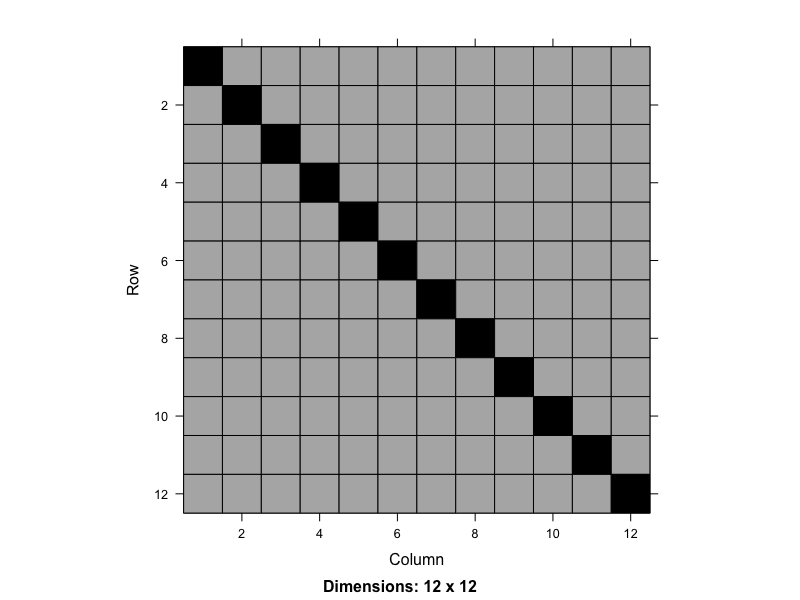

In [5]:
library('Matrix')

Sigma <- getVarCov(weightloss.lme.0, individual='1', type='marginal')$`1`
print(Sigma)
image(as(Sigma,'Matrix'))

Unsurprisingly, this is *compound symmetric*. So what options do we have? Using a process that we will detail in the materials next week, we should in theory be able to fit a model per-subject that contains all the effects up to a 2-way interaction. This would have the form `random= ~ 1 + diet + exercises + time + diet:exercises + diet:time + exercises:time`. This also echoes the error terms used in the repeated measures ANOVA. Unfortunately, the covariance structure implied by this specification is too complex to fit. This is not a problem of theory, rather it is a limitation of the software. The REML estimation procedure will keep iterating, never converge and then stop. So, we are forced to simplify. In order to do so, we forget the interactions and just fit the main effects of each term.

In [6]:
weightloss.lme.1 <- lme(weight ~ diet*exercises*time, random= ~ 1 + diet + exercises + time|id, data=weightloss.long, control=lmeControl(opt='optim'))

This still requires a little fiddling-around by setting a slightly different option for the optimisation algorithm. The default is a tad flaky and so adding this option is often a first port-of-call to see if we can get the model to converge.

Importantly, the implication of this specification is that the effect of `diet`, `exercises` and `time` are allowed to vary from subject-to-subject. We assume that there is something fundamental about different individuals that changes how their weight responds to `diet`, `exercises` and `time`. However, we are forced to assume that the way these aspects interact is the *same* irrespective of the individual. We will discuss more about these interpretations in the materials this week. For now, the point is to see how different random effects structures change the covariance matrix.

            1          2          3          4           5          6
1  1.32509899 0.17708871 0.07621244 0.15019043 0.043238445 0.11721644
2  0.17708871 1.52806888 0.13098837 0.25998026 0.074707230 0.20369912
3  0.07621244 0.13098837 1.27867294 0.11146059 0.032185008 0.08696094
4  0.15019043 0.25998026 0.11146059 1.44323870 0.063653793 0.17344362
5  0.04323844 0.07470723 0.03218501 0.06365379 1.240963739 0.05044425
6  0.11721644 0.20369912 0.08696094 0.17344362 0.050444247 1.35891521
7  0.01634016 0.02860689 0.01265723 0.02492396 0.007922025 0.02018875
8  0.09031816 0.15759878 0.06743316 0.13471379 0.039390810 0.10667143
9  0.10307581 0.17701502 0.07618509 0.15012430 0.043215160 0.11715438
10 0.17705380 0.30600692 0.13096102 0.25991413 0.074683945 0.20363706
11 0.07617753 0.13091468 0.05665731 0.11139446 0.032161723 0.08689888
12 0.15015552 0.25990657 0.11143324 0.22118429 0.063630508 0.17338156
             7          8          9         10         11         12
1  0.016340164 0.090

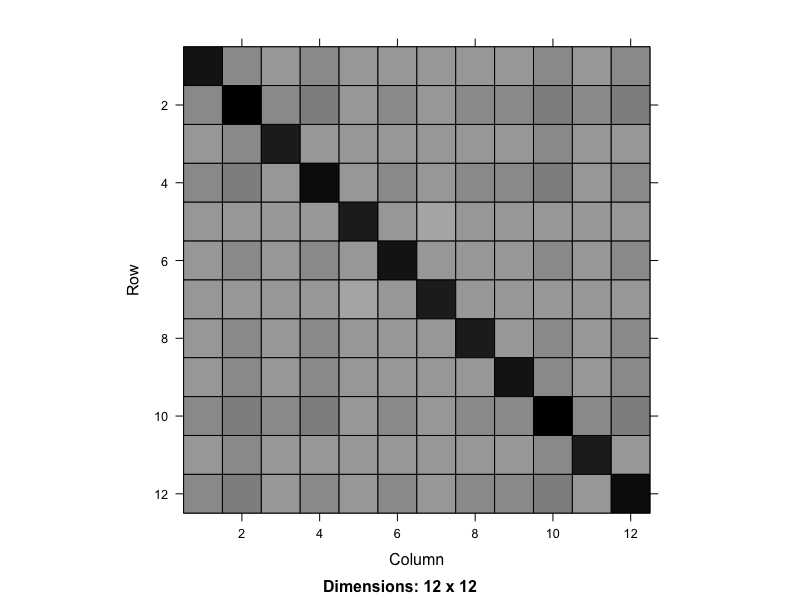

In [7]:
Sigma <- getVarCov(weightloss.lme.1, individual='1', type='marginal')$`1`
print(Sigma)
image(as(Sigma,'Matrix'))

So notice that we have now achieved the aim we had last week of a completely unstructured covariance matrix. This was too complex to fit using `gls()`, but we have managed it using a mixed-effects model.

<div class="alert alert-block alert-info"> 
<b>ACTIVITY 3</b> An alternative assumption about the random-effects structure would be that both <code>diet</code> and <code>exercises</code> affect different people in different ways, but that <code>time</code> affects everyone in the same way. How could you integrate this assumption into the model? Can you now include the interaction terms as well? What does the covariance structure look like?
</div>

<div class="alert alert-block alert-info"> 
<b>ACTIVITY 4</b> Can you now produce the extra tests for the new model with the more general covariance structure? Does anything substantive change in terms of the omnibus tests, follow-up tests or plots? What does this suggest about the sensitivity of our inference to the covariance assumptions?
</div>

## Within-subject and Between-subject Factors
We can also revisit the example from last week of the `anxiety` dataset which contains both a *within-subject* and *between-subjects* factor. We load and wrangle the data below 

In [8]:
data('anxiety')

# repeats and number of subjects
t <- 3
n <- 45

# reshape wide -> long
anxiety.long <- melt(anxiety,                 # wide data frame
                     id.vars=c('id','group'), # both id and group stay fixed
                     variable.name='time',    # name for the new predictor
                     value.name='score')      # name for the new outcome

anxiety.long           <- anxiety.long [order(anxiety.long$id),] # order by ID
rownames(anxiety.long) <- seq(1,n*t)                             # fix row names
anxiety.long$id        <- as.factor(anxiety.long$id)             # id as factor
anxiety.long$group     <- as.factor(anxiety.long$group)          # group as factor
anxiety.long$time      <- as.factor(anxiety.long$time)           # time as factor

head(anxiety.long)

  id group time score
1  1  grp1   t1  14.1
2  1  grp1   t2  14.4
3  1  grp1   t3  14.1
4  2  grp1   t1  14.5
5  2  grp1   t2  14.6
6  2  grp1   t3  14.3

### Random-effect Specification
Unlike the previous example, because there are no replications here we are forced to only use a *random intercept* per-subject. Again, the logic of doing this will be more explicitly laid out in the materials this week. For now, we will just explore what these models give us and the options we have available. 

We fit the model below using `random= ~ 1|id` for the random effects

In [9]:
anxiety.lme.0 <- lme(score ~ group*time, random= ~ 1|id, data=anxiety.long)
summary(anxiety.lme.0)

Linear mixed-effects model fit by REML
  Data: anxiety.long 
       AIC     BIC    logLik
  278.6349 309.834 -128.3174

Random effects:
 Formula: ~1 | id
        (Intercept)  Residual
StdDev:     1.53169 0.2903382

Fixed effects:  score ~ group * time 
                     Value Std.Error DF   t-value p-value
(Intercept)      17.086667 0.4025229 84  42.44893  0.0000
groupgrp2        -0.440000 0.5692534 42  -0.77294  0.4439
groupgrp3        -0.073333 0.5692534 42  -0.12882  0.8981
timet2           -0.160000 0.1060165 84  -1.50920  0.1350
timet3           -0.580000 0.1060165 84  -5.47084  0.0000
groupgrp2:timet2 -0.020000 0.1499300 84  -0.13340  0.8942
groupgrp3:timet2 -1.840000 0.1499300 84 -12.27239  0.0000
groupgrp2:timet3 -0.540000 0.1499300 84  -3.60168  0.0005
groupgrp3:timet3 -2.873333 0.1499300 84 -19.16450  0.0000
 Correlation: 
                 (Intr) grpgr2 grpgr3 timet2 timet3 grp2:2 grp3:2 grp2:3
groupgrp2        -0.707                                                 
groupg

As expected, there are only two variance terms and we have a compound symmetric structure again.

<div class="alert alert-block alert-info"> 
<b>ACTIVITY 5</b> Can you confirm the covariance structure for this model by extracting and visualising it?
</div>

We can then continue our usual approach of generating omnibus tests

In [10]:
Anova(anxiety.lme.0)

Analysis of Deviance Table (Type II tests)

Response: score
              Chisq Df Pr(>Chisq)    
group        8.7036  2    0.01288 *  
time       789.8190  2    < 2e-16 ***
group:time 440.7504  4    < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

and can plot the `group:time` effect

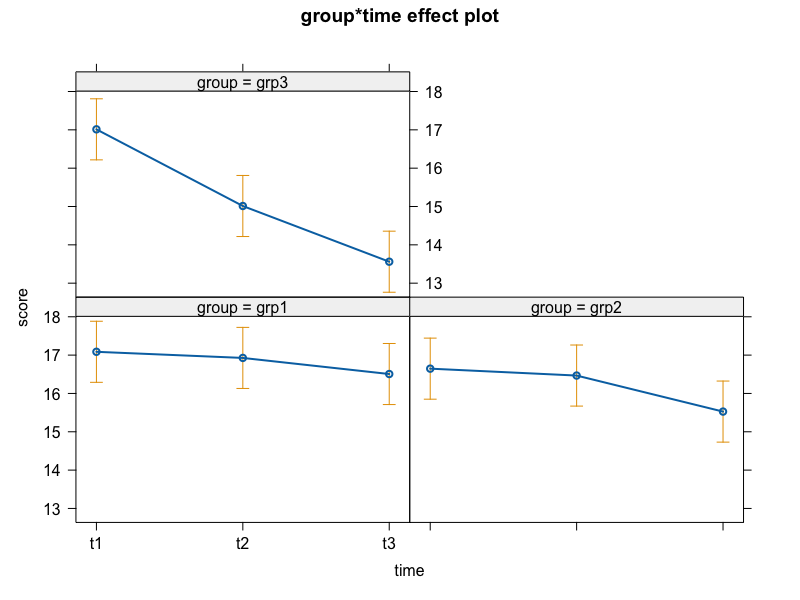

In [11]:
plot(effect('group:time', anxiety.lme.0), x.var='time')

where there appears to be a clear change in the effect of `time` depending upon the `group`.

<div class="alert alert-block alert-info"> 
<b>ACTIVITY 6</b> Can you follow-up this interaction using <code>emmeans</code>?
</div>

### Multilevel Conceptualisation
As we saw earlier, we can present the multilevel version of this model. Again, the process of building this will be given in much more detail in the materials this week, so do not worry about understanding every nuance of this

$$
\begin{alignat*}{1}
\text{Level 1}\\
    y_{ijk} &= \mu_{i} + \alpha_{j} + (\alpha\beta)_{jk} + \eta_{ijk} \\
    \quad \\
\text{Level 2} \\
    \mu_{i} &= \mu + \beta_{k} + \xi_{i}
\end{alignat*}
$$

For now, notice that the *between-subjects* factor enters at Level 2. This again echoes how this effects are split into error terms in the repeated measures ANOVA.

### Including a `weights=` Structure
As mentioned, the lack of replications limits the random-effects structure. However, an advantage of `lme()` is that we have access to same `weights=` options as `gls()`. This means that we can make the structure more general across the levels of `group` by allowing different variances. The syntax for this is

In [12]:
anxiety.lme.1 <- lme(score ~ group*time, random= ~ 1|id, weights=varIdent(form= ~ 1|group), data=anxiety.long)
summary(anxiety.lme.1)

Linear mixed-effects model fit by REML
  Data: anxiety.long 
       AIC      BIC    logLik
  281.9984 318.8701 -127.9992

Random effects:
 Formula: ~1 | id
        (Intercept)  Residual
StdDev:    1.531916 0.3013531

Variance function:
 Structure: Different standard deviations per stratum
 Formula: ~1 | group 
 Parameter estimates:
    grp1     grp2     grp3 
1.000000 0.878552 1.006210 
Fixed effects:  score ~ group * time 
                     Value Std.Error DF   t-value p-value
(Intercept)      17.086667 0.4031194 84  42.38611  0.0000
groupgrp2        -0.440000 0.5688843 42  -0.77344  0.4436
groupgrp3        -0.073333 0.5701631 42  -0.12862  0.8983
timet2           -0.160000 0.1100386 84  -1.45404  0.1497
timet3           -0.580000 0.1100386 84  -5.27088  0.0000
groupgrp2:timet2 -0.020000 0.1464735 84  -0.13654  0.8917
groupgrp3:timet2 -1.840000 0.1561020 84 -11.78717  0.0000
groupgrp2:timet3 -0.540000 0.1464735 84  -3.68667  0.0004
groupgrp3:timet3 -2.873333 0.1561020 84 -18.40677 

<div class="alert alert-block alert-info"> 
<b>ACTIVITY 7</b> Use the data to identify the <code>id</code> of the first subject from each level of <code>group</code>. Extract the covariance matrices for each of these subjects and compare them.
</div>

### Model Comparisons
We can also use model comparisons to determine whether these types of choice are supported by the data. For instance, to see if the `weights=` structure is needed, we can use

In [13]:
mod.0 <- lme(score ~ group*time, random= ~ 1|id,                                    data=anxiety.long, method='ML')
mod.1 <- lme(score ~ group*time, random= ~ 1|id, weights=varIdent(form= ~ 1|group), data=anxiety.long, method='ML')

anova(mod.0,mod.1)

      Model df      AIC      BIC    logLik   Test   L.Ratio p-value
mod.0     1 11 261.5386 293.4966 -119.7693                         
mod.1     2 13 264.8566 302.6252 -119.4283 1 vs 2 0.6819275  0.7111

<div class="alert alert-block alert-info"> 
<b>ACTIVITY 8</b> Does this result suggest that a different variance per-level of <code>group</code> is needed or not?
</div>

## Model Assumptions